In [ ]:
from pathlib import Path
import pandas as pd

file_path = Path("taxi.csv")

data = pd.read_csv(file_path, index_col=0, parse_dates=[0])

print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None
                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32


In [ ]:

data.sort_index(inplace=True)


data = data.resample("1H").sum()

print(data.head())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


C:\Users\Juan\AppData\Local\Temp\ipykernel_24672\3363840899.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample("1H").sum()


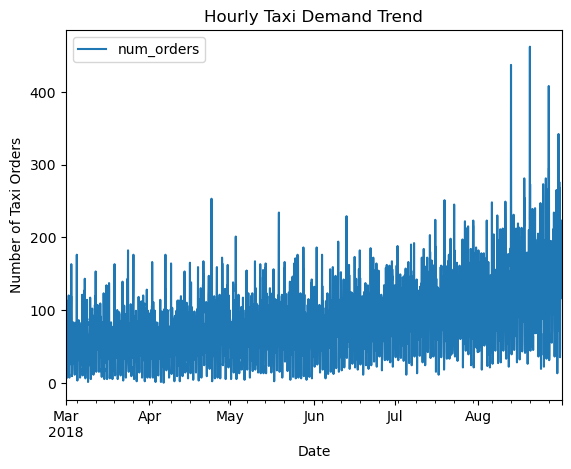

In [19]:
import matplotlib.pyplot as plt

data.plot()

plt.title("Hourly Taxi Demand Trend")
plt.xlabel("Date")
plt.ylabel("Number of Taxi Orders")

plt.show()

In [20]:
def make_features(data, max_lag, rolling_mean_size):
    data["hour"] = data.index.hour
    data["dayofweek"] = data.index.dayofweek
    data["day"] = data.index.day
    data["month"] = data.index.month

    for i in range(1, max_lag + 1):
        data[f'lag_{i}'] = data["num_orders"].shift(i)

    data["rolling_mean"] = data["num_orders"].shift().rolling(rolling_mean_size).mean()
    

In [21]:
make_features(data, 10, 24)

data = data.dropna()

In [22]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, shuffle=False, test_size=0.1)


In [23]:
features = data.drop(columns="num_orders").columns

X_train = train[features]
y_train = train["num_orders"]

X_test = test[features]
y_test = test["num_orders"]

print(X_train.head())

                     hour  dayofweek  day  month  lag_1  lag_2  lag_3  lag_4  \
datetime                                                                       
2018-03-02 00:00:00     0          4    2      3   58.0  113.0   66.0   61.0   
2018-03-02 01:00:00     1          4    2      3   90.0   58.0  113.0   66.0   
2018-03-02 02:00:00     2          4    2      3  120.0   90.0   58.0  113.0   
2018-03-02 03:00:00     3          4    2      3   75.0  120.0   90.0   58.0   
2018-03-02 04:00:00     4          4    2      3   64.0   75.0  120.0   90.0   

                     lag_5  lag_6  lag_7  lag_8  lag_9  lag_10  rolling_mean  
datetime                                                                      
2018-03-02 00:00:00   45.0   73.0   44.0   43.0   66.0    48.0     56.833333  
2018-03-02 01:00:00   61.0   45.0   73.0   44.0   43.0    66.0     55.416667  
2018-03-02 02:00:00   66.0   61.0   45.0   73.0   44.0    43.0     56.875000  
2018-03-02 03:00:00  113.0   66.0   61.0   4

In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error
median_pred = np.median(y_train)

y_pred_baseline_train = [median_pred] * len(y_train)
y_pred_baseline_test = [median_pred] * len(y_test)

rmse_baseline_train = np.sqrt(mean_squared_error(y_train, y_pred_baseline_train))
rmse_baseline_test = np.sqrt(mean_squared_error(y_test, y_pred_baseline_test))

In [25]:
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

In [26]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    return rmse_train, rmse_test


In [15]:
results = []

# Linear Regression
lr = LinearRegression()
rmse_train, rmse_test = evaluate_model(lr, X_train, y_train, X_test, y_test)
results.append(["Linear Regression", rmse_train, rmse_test])

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rmse_train, rmse_test = evaluate_model(rf, X_train, y_train, X_test, y_test)
results.append(["Random Forest", rmse_train, rmse_test])

# LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
rmse_train, rmse_test = evaluate_model(lgb_model, X_train, y_train, X_test, y_test)
results.append(["LightGBM", rmse_train, rmse_test])

# Baseline
results.append(["Baseline (Median)", rmse_baseline_train, rmse_baseline_test])


results_df = pd.DataFrame(results, columns=["Model", "RMSE Train", "RMSE Test"])
print(results_df)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2225
[LightGBM] [Info] Number of data points in the train set: 3952, number of used features: 15
[LightGBM] [Info] Start training from score 78.451417
               Model  RMSE Train  RMSE Test
0  Linear Regression   30.134768  51.148071
1      Random Forest    8.579497  43.501381
2           LightGBM   13.752725  41.843811
3  Baseline (Median)   38.858992  87.210938


In [27]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 100}


Multiple models were developed to predict the number of hourly taxi orders using time series techniques.

Feature engineering was enhanced by incorporating calendar variables (hour, day of the week, day, and month), along with lag features and a 24-hour rolling mean, enabling the models to capture more complex temporal patterns.

Several models (Linear Regression, Random Forest, and LightGBM) were compared alongside a median-based baseline. Tree-based models significantly outperformed the baseline, demonstrating their ability to capture non-linear relationships.

Model performance was evaluated on both training and test sets, with LightGBM achieving the best results, reaching an RMSE below 48 and meeting the project objective.

Finally, the use of TimeSeriesSplit provided a more robust estimation of model performance for time-dependent data.